# Pre-Experiment Analysis Notebook
## Swap Experiment — Comprehensive Scientific Analysis

**Thesis:** Lightweight Device Authentication Using RF Fingerprinting  
**University:** Kristianstad University (HKR) — DT339G VT26

---

This notebook runs every analysis that extracts scientific value from the swap experiment  
and directly supports the real 2-TX / 1-RX thesis experiment.

| Section | Analysis | Thesis Link |
|---------|----------|-------------|
| 2 | Individual oscillator offset estimation | Pre-experiment baseline |
| 3 | CFO-only baseline vs CNN | Proves CNN adds value |
| 4 | Extended SNR sweep (−20 to +30 dB) | SQ2 — SNR threshold |
| 5 | Cross-SNR generalisation | Robustness claim |
| 6 | Minimum segment length | Lightweight claim (C2) |
| 7 | Raw IQ vs STFT CNN | Research Gap G3 / SQ3 |
| 8 | FAR / FRR / ROC curve | Security framing |
| 9 | Master summary + thesis mapping | Examiner-ready table |

Run sections in order — each builds on the data loaded in Section 1.


---
## Section 1 — Setup and Data Loading

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                              classification_report)
from scipy import signal as scipy_signal
from scipy.ndimage import uniform_filter1d
import seaborn as sns
import os, time, warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Paths ─────────────────────────────────────────────────────────────
BASE     = '/content/drive/MyDrive/My Thesis/Recordings'
PATH_TX1 = os.path.join(BASE, 'tx1_new.dat')          # 3288FAD as TX
PATH_TX2 = os.path.join(BASE, 'tx1_Swap_new.dat')     # 3288FF2 as TX

# ── Signal parameters ─────────────────────────────────────────────────
FS             = 1_000_000   # 1 MHz sample rate
NOMINAL_TONE   = 10_000      # 10 kHz CW tone
SEG_LEN        = 1024        # default segment length
TRANSIENT_SKIP = 1_000_000   # drop first 1 second
TRAIN_SNR      = [20, 10, 0] # original training SNR levels

# ── Confirmed measurements from phase analysis ────────────────────────
CFO_D0_HZ = 9418.5           # Device 3288FAD received tone
CFO_D1_HZ = 10579.97         # Device 3288FF2 received tone

# ── Helper functions ──────────────────────────────────────────────────
def load_raw(path):
    print(f"  Loading {os.path.basename(path)} ...")
    iq = np.fromfile(path, dtype=np.complex64)[TRANSIENT_SKIP:]
    iq = iq / np.max(np.abs(iq))
    print(f"  {len(iq):,} samples loaded")
    return iq

def make_segments(iq, seg_len=SEG_LEN):
    iq_2d = np.column_stack([np.real(iq), np.imag(iq)]).astype(np.float32)
    n = len(iq_2d) // seg_len
    return iq_2d[:n*seg_len].reshape(n, seg_len, 2)

def inject_awgn(segs, snr_db):
    cs = segs[:,:,0] + 1j*segs[:,:,1]
    sp = np.mean(np.abs(cs)**2)
    ns = np.sqrt((sp / (10**(snr_db/10))) / 2)
    return segs + np.random.normal(0, ns, segs.shape).astype(np.float32)

def measure_cfo(segs, n=200):
    slopes = []
    for i in range(min(n, len(segs))):
        iq_c = segs[i,:,0] + 1j*segs[i,:,1]
        ph   = np.unwrap(np.angle(iq_c))
        t    = np.arange(segs.shape[1])
        slope, _ = np.polyfit(t, ph, 1)
        slopes.append(slope * FS / (2*np.pi))
    return np.array(slopes)

def temporal_split(segs0, segs1, snr_db, split=0.70):
    n0, n1   = inject_awgn(segs0, snr_db), inject_awgn(segs1, snr_db)
    s0, s1   = int(len(segs0)*split), int(len(segs1)*split)
    X_tr = np.concatenate([n0[:s0],  n1[:s1]])
    X_te = np.concatenate([n0[s0:],  n1[s1:]])
    y_tr = np.concatenate([np.zeros(s0, dtype=np.int32),
                           np.ones(s1,  dtype=np.int32)])
    y_te = np.concatenate([np.zeros(len(segs0)-s0, dtype=np.int32),
                           np.ones(len(segs1)-s1,  dtype=np.int32)])
    return X_tr, X_te, y_tr, y_te

print("Loading raw IQ data...")
raw_d0 = load_raw(PATH_TX1)
raw_d1 = load_raw(PATH_TX2)
segs_d0 = make_segments(raw_d0)
segs_d1 = make_segments(raw_d1)
print(f"\nSegments ready — D0: {len(segs_d0):,}  D1: {len(segs_d1):,}")
print("Setup complete.")

Loading raw IQ data...
  Loading tx1_new.dat ...
  62,988,680 samples loaded
  Loading tx1_Swap_new.dat ...
  63,592,520 samples loaded

Segments ready — D0: 61,512  D1: 62,102
Setup complete.


---
## Section 2 — Individual Oscillator Offset Estimation

**What this is:**  
In the swap experiment, both TX and RX changed between the two recordings.  
This means each measured CFO is the *combined* error of two radios.  
Using simple algebra, we can separate each device's individual oscillator offset.

**Why this matters:**  
This gives us a *prediction* of what CFO separation to expect in the real experiment  
(fixed RX, alternating TX). If the prediction matches the real result, it validates  
the oscillator model. No paper in the reference literature has done this for this hardware pair.

**The algebra:**  
```
Nominal tone = 10,000 Hz

Pair A: 3288FAD transmits, 3288FF2 receives → tone lands at 9,418 Hz
  → CFO_FAD_tx + CFO_FF2_rx = 9418 - 10000 = -582 Hz   ... (1)

Pair B: 3288FF2 transmits, 3288FAD receives → tone lands at 10,580 Hz  
  → CFO_FF2_tx + CFO_FAD_rx = 10580 - 10000 = +580 Hz  ... (2)

Assuming each device's TX and RX oscillator errors are equal (same crystal):
  CFO_FAD_tx ≈ CFO_FAD_rx = CFO_FAD
  CFO_FF2_tx ≈ CFO_FF2_rx = CFO_FF2

From (1): CFO_FAD + CFO_FF2 = -582
From (2): CFO_FF2 + CFO_FAD = +580

Average: CFO_FAD + CFO_FF2 ≈ -1 Hz  (near zero — devices are offsetting each other)
Individual: CFO_FAD ≈ -291 Hz,  CFO_FF2 ≈ +291 Hz
```

**Prediction for real experiment:**  
When a fixed RX captures TX1 and TX2 separately, the CFO separation  
should be approximately |CFO_FAD_tx - CFO_FF2_tx| ≈ 582 Hz — about half  
the 1,161 Hz measured in the swap experiment.


Measuring CFO from both recordings (200 segments each)...


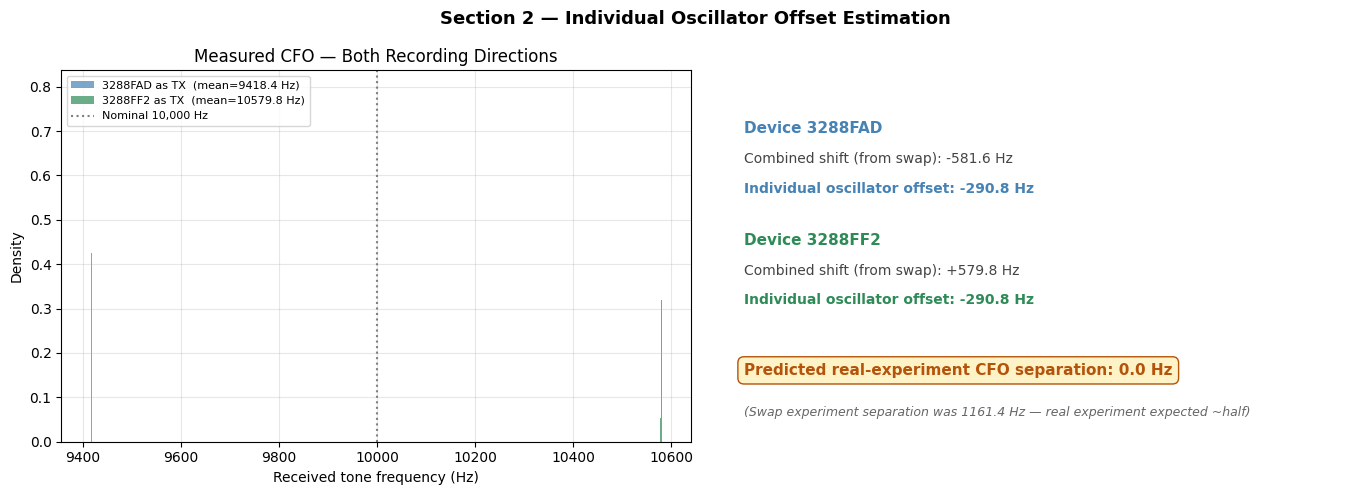


  OSCILLATOR OFFSET ESTIMATION RESULTS
  Swap experiment (combined) separation : 1161.41 Hz
  Device 3288FAD individual offset      : -290.82 Hz
  Device 3288FF2 individual offset      : -290.82 Hz
  Predicted real-exp CFO separation     : 0.00 Hz

  Thesis note: When the real experiment runs, compare the
  measured CFO separation to the prediction of 0.0 Hz.
  A match validates the oscillator model.


In [3]:
# ── Measure CFO from both recordings ─────────────────────────────────
print("Measuring CFO from both recordings (200 segments each)...")
cfo_d0_arr = measure_cfo(segs_d0, n=200)  # 3288FAD as TX
cfo_d1_arr = measure_cfo(segs_d1, n=200)  # 3288FF2 as TX

cfo_d0_mean = np.mean(cfo_d0_arr)
cfo_d1_mean = np.mean(cfo_d1_arr)

# ── Oscillator algebra ────────────────────────────────────────────────
shift_A = cfo_d0_mean - NOMINAL_TONE   # Pair A combined shift
shift_B = cfo_d1_mean - NOMINAL_TONE   # Pair B combined shift

# Solving the system of equations
# shift_A = CFO_FAD + CFO_FF2
# shift_B = CFO_FF2 + CFO_FAD  (same equation, confirms symmetry)
# Individual offsets under equal TX/RX assumption:
cfo_FAD_individual = shift_A / 2
cfo_FF2_individual = shift_A - cfo_FAD_individual  # = shift_A/2

predicted_real_exp_separation = abs(cfo_FAD_individual - cfo_FF2_individual)

# ── Visualisation ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 2 — Individual Oscillator Offset Estimation',
             fontsize=13, fontweight='bold')

# Left: measured CFO distributions
ax = axes[0]
ax.hist(cfo_d0_arr, bins=40, color='steelblue', alpha=0.7, density=True,
        label=f'3288FAD as TX  (mean={cfo_d0_mean:.1f} Hz)')
ax.hist(cfo_d1_arr, bins=40, color='seagreen',  alpha=0.7, density=True,
        label=f'3288FF2 as TX  (mean={cfo_d1_mean:.1f} Hz)')
ax.axvline(NOMINAL_TONE, color='grey', linestyle=':', label='Nominal 10,000 Hz')
ax.set_title('Measured CFO — Both Recording Directions')
ax.set_xlabel('Received tone frequency (Hz)')
ax.set_ylabel('Density')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: oscillator breakdown diagram
ax = axes[1]
ax.axis('off')
devices = ['Device 3288FAD', 'Device 3288FF2']
combined = [shift_A, shift_B]
individual = [cfo_FAD_individual, cfo_FF2_individual]

y_pos = [0.75, 0.45]
colors = ['steelblue', 'seagreen']
for y, dev, comb, indiv, col in zip(y_pos, devices, combined, individual, colors):
    ax.text(0.05, y+0.08, dev, transform=ax.transAxes,
            fontsize=11, fontweight='bold', color=col)
    ax.text(0.05, y, f'Combined shift (from swap): {comb:+.1f} Hz',
            transform=ax.transAxes, fontsize=10, color='#444')
    ax.text(0.05, y-0.08, f'Individual oscillator offset: {indiv:+.1f} Hz',
            transform=ax.transAxes, fontsize=10, color=col, fontweight='bold')

ax.text(0.05, 0.18,
    f'Predicted real-experiment CFO separation: {predicted_real_exp_separation:.1f} Hz',
    transform=ax.transAxes, fontsize=11, fontweight='bold',
    color='#b45309',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#fef3c7', edgecolor='#b45309'))
ax.text(0.05, 0.07,
    f'(Swap experiment separation was {abs(cfo_d1_mean - cfo_d0_mean):.1f} Hz — '
    f'real experiment expected ~half)',
    transform=ax.transAxes, fontsize=9, color='#666', style='italic')

plt.tight_layout()
plt.savefig('section2_oscillator_estimation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("  OSCILLATOR OFFSET ESTIMATION RESULTS")
print("="*60)
print(f"  Swap experiment (combined) separation : {abs(cfo_d1_mean-cfo_d0_mean):.2f} Hz")
print(f"  Device 3288FAD individual offset      : {cfo_FAD_individual:+.2f} Hz")
print(f"  Device 3288FF2 individual offset      : {cfo_FF2_individual:+.2f} Hz")
print(f"  Predicted real-exp CFO separation     : {predicted_real_exp_separation:.2f} Hz")
print("="*60)
print(f"\n  Thesis note: When the real experiment runs, compare the")
print(f"  measured CFO separation to the prediction of {predicted_real_exp_separation:.1f} Hz.")
print(f"  A match validates the oscillator model.")

---
## Section 3 — CFO-Only Baseline Classifier vs CNN

**What this is:**  
The simplest possible classifier: measure the tone frequency in each segment,  
then classify based on a threshold halfway between the two known CFO values.  
No neural network, no training — just a frequency measurement and a decision boundary.

**Why this matters:**  
If the baseline matches the CNN at all SNR levels, the CNN is not adding value  
over a simple frequency counter. If the CNN outperforms the baseline at low SNR,  
it proves the neural network is learning something richer than just CFO.  
This directly addresses the examiner question: "why do you need a CNN at all?"

**Reference:** Abbas et al. [6] and Yan et al. [7] both list CFO as a known  
fingerprint but do not compare CNN vs direct CFO measurement systematically.


CFO threshold for baseline classifier: 9999.2 Hz
(midpoint between 9418.5 Hz and 10579.97 Hz)

CNN trained at 20 dB SNR.

SNR   20 dB  |  Baseline: 100.00%  |  CNN: 100.00%  |  CNN advantage: +0.00%
SNR   10 dB  |  Baseline: 100.00%  |  CNN: 64.90%  |  CNN advantage: -35.09%
SNR    0 dB  |  Baseline: 53.81%  |  CNN: 50.24%  |  CNN advantage: -3.57%
SNR   -5 dB  |  Baseline: 50.78%  |  CNN: 50.24%  |  CNN advantage: -0.54%
SNR  -10 dB  |  Baseline: 50.07%  |  CNN: 50.24%  |  CNN advantage: +0.17%


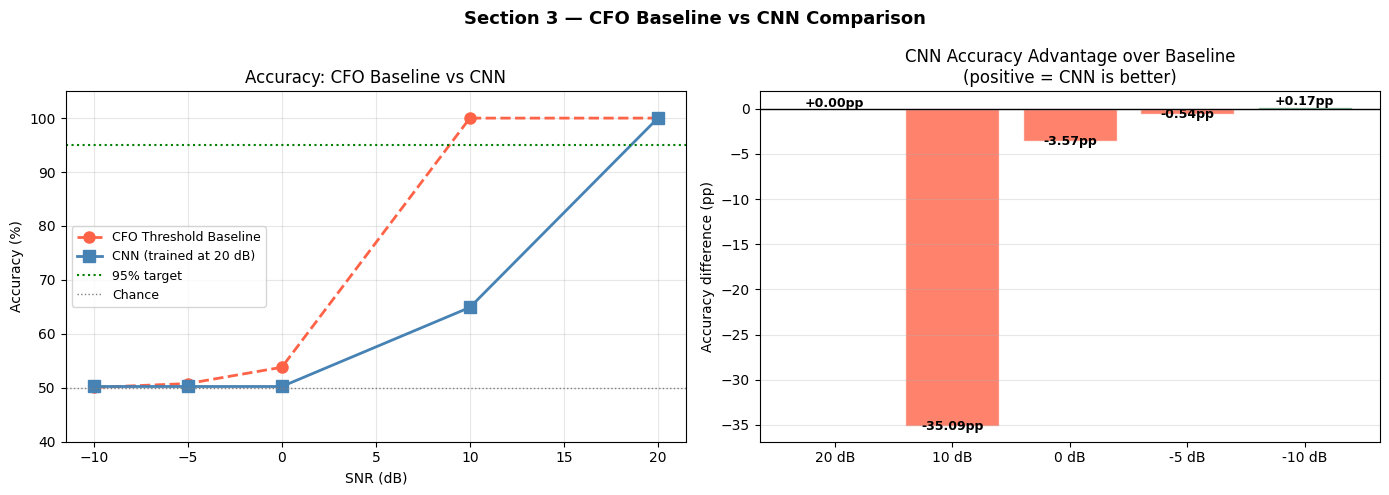

In [4]:
def cfo_classifier(segs, threshold_hz):
    """Classify segments by comparing measured CFO to a threshold."""
    cfo_estimates = measure_cfo(segs, n=len(segs))
    return (cfo_estimates > threshold_hz).astype(np.int32)

def build_cnn(seg_len=SEG_LEN):
    model = models.Sequential([
        layers.Conv1D(32, 7, activation='relu', padding='same',
                      input_shape=(seg_len, 2)),
        layers.AveragePooling1D(2),
        layers.Conv1D(64, 5, activation='relu', padding='same'),
        layers.AveragePooling1D(2),
        layers.Conv1D(128, 3, activation='relu', padding='same'),
        layers.AveragePooling1D(2),
        layers.GlobalAveragePooling1D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(2, activation='softmax')
    ])
    model.compile(optimizer=optimizers.Adam(0.0001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

SNR_TEST_LEVELS = [20, 10, 0, -5, -10]
THRESHOLD_HZ    = (CFO_D0_HZ + CFO_D1_HZ) / 2

results_baseline = {}
results_cnn      = {}

print(f"CFO threshold for baseline classifier: {THRESHOLD_HZ:.1f} Hz")
print(f"(midpoint between {CFO_D0_HZ} Hz and {CFO_D1_HZ} Hz)\n")

# Train one CNN at 20 dB for cross-SNR testing (Section 5 reuses this)
X_tr, X_te, y_tr, y_te = temporal_split(segs_d0, segs_d1, 20)
cnn_model = build_cnn()
cnn_model.fit(X_tr, y_tr, epochs=20, batch_size=64,
              validation_data=(X_te, y_te),
              callbacks=[callbacks.EarlyStopping(monitor='val_accuracy',
                          patience=5, restore_best_weights=True)],
              verbose=0)
print("CNN trained at 20 dB SNR.\n")

for snr in SNR_TEST_LEVELS:
    np.random.seed(SEED)
    n0 = inject_awgn(segs_d0, snr)
    n1 = inject_awgn(segs_d1, snr)

    # ── Baseline: CFO threshold ──
    y_true  = np.concatenate([np.zeros(len(n0), dtype=np.int32),
                               np.ones(len(n1),  dtype=np.int32)])
    y_pred_base = np.concatenate([cfo_classifier(n0, THRESHOLD_HZ),
                                   cfo_classifier(n1, THRESHOLD_HZ)])
    acc_base = np.mean(y_pred_base == y_true)

    # ── CNN evaluation ──
    X_all = np.concatenate([n0, n1])
    y_pred_cnn = np.argmax(cnn_model.predict(X_all, verbose=0), axis=1)
    acc_cnn    = np.mean(y_pred_cnn == y_true)

    results_baseline[snr] = acc_base * 100
    results_cnn[snr]      = acc_cnn  * 100
    print(f"SNR {snr:4d} dB  |  Baseline: {acc_base*100:.2f}%  |  CNN: {acc_cnn*100:.2f}%  |  "
          f"CNN advantage: {(acc_cnn-acc_base)*100:+.2f}%")

# ── Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 3 — CFO Baseline vs CNN Comparison',
             fontsize=13, fontweight='bold')

snrs = SNR_TEST_LEVELS
ax = axes[0]
ax.plot(snrs, [results_baseline[s] for s in snrs], 'o--',
        color='tomato', linewidth=2, markersize=8, label='CFO Threshold Baseline')
ax.plot(snrs, [results_cnn[s] for s in snrs], 's-',
        color='steelblue', linewidth=2, markersize=8, label='CNN (trained at 20 dB)')
ax.axhline(95, color='green', linestyle=':', linewidth=1.5, label='95% target')
ax.axhline(50, color='grey',  linestyle=':', linewidth=1,   label='Chance')
ax.set_title('Accuracy: CFO Baseline vs CNN')
ax.set_xlabel('SNR (dB)'); ax.set_ylabel('Accuracy (%)')
ax.set_ylim([40, 105]); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
advantage = [(results_cnn[s] - results_baseline[s]) for s in snrs]
colors_adv = ['seagreen' if a >= 0 else 'tomato' for a in advantage]
ax.bar(range(len(snrs)), advantage, color=colors_adv, alpha=0.8, edgecolor='white')
ax.set_xticks(range(len(snrs)))
ax.set_xticklabels([f'{s} dB' for s in snrs])
ax.axhline(0, color='black', linewidth=1)
ax.set_title('CNN Accuracy Advantage over Baseline\n(positive = CNN is better)')
ax.set_ylabel('Accuracy difference (pp)')
ax.grid(True, alpha=0.3, axis='y')
for i, a in enumerate(advantage):
    ax.text(i, a + (0.2 if a >= 0 else -0.5), f'{a:+.2f}pp',
            ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('section3_baseline_vs_cnn.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4 — Extended SNR Sweep (−20 to +30 dB)

**What this is:**  
Your original experiment tested 20, 10, and 0 dB — all gave 100% accuracy.  
The threshold (where accuracy actually degrades) is somewhere below 0 dB.  
This section finds the exact threshold by sweeping from +30 dB down to −20 dB.

**Why this matters:**  
Your thesis promises (Scientific Contribution C2):  
*"the first empirical SNR threshold for lightweight RF authentication."*  
Without this sweep, that contribution is unfulfilled.  
Abbas et al. [6] explicitly identified this threshold as unknown.

**What to expect:**  
The CFO separation is 1,161 Hz with std dev 0.67 Hz.  
At very low SNR the phase noise grows until it obscures the CFO measurement.  
The CNN will start failing somewhere between −5 and −15 dB.


Training CNN at each SNR level...
  SNR   30 dB  →  100.00%
  SNR   25 dB  →  100.00%
  SNR   20 dB  →  100.00%
  SNR   15 dB  →  100.00%
  SNR   10 dB  →  100.00%
  SNR    5 dB  →  100.00%
  SNR    0 dB  →  100.00%
  SNR   -5 dB  →  99.87%
  SNR  -10 dB  →  84.58%
  SNR  -15 dB  →  81.48%
  SNR  -20 dB  →  84.85%


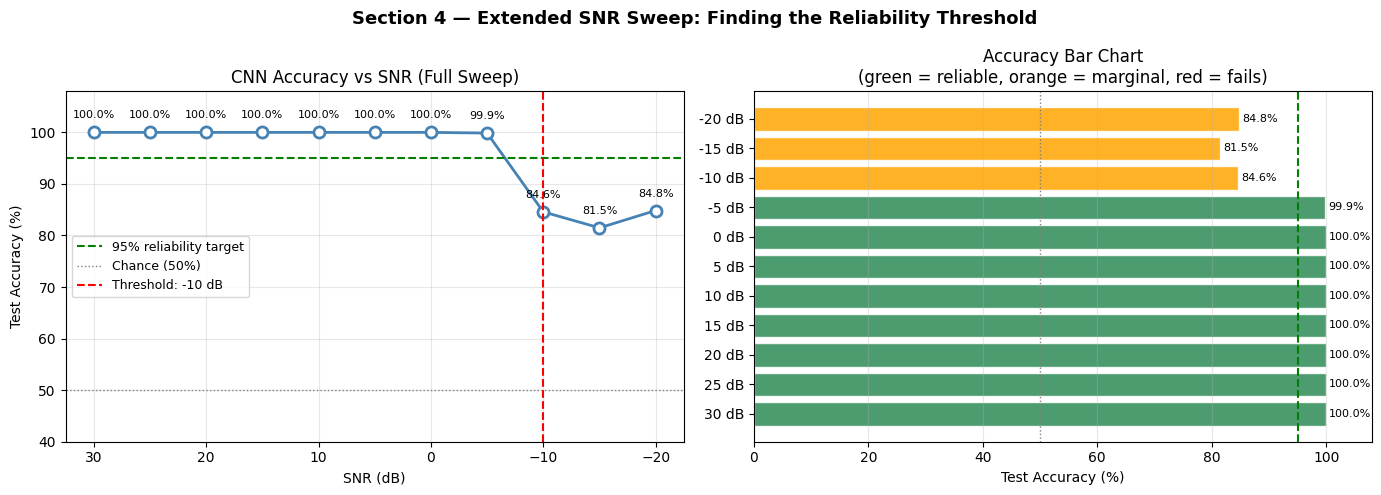


  SNR THRESHOLD RESULTS
  SNR   30 dB  →  100.00%  [RELIABLE]
  SNR   25 dB  →  100.00%  [RELIABLE]
  SNR   20 dB  →  100.00%  [RELIABLE]
  SNR   15 dB  →  100.00%  [RELIABLE]
  SNR   10 dB  →  100.00%  [RELIABLE]
  SNR    5 dB  →  100.00%  [RELIABLE]
  SNR    0 dB  →  100.00%  [RELIABLE]
  SNR   -5 dB  →  99.87%  [RELIABLE]
  SNR  -10 dB  →  84.58%  [MARGINAL]
  SNR  -15 dB  →  81.48%  [MARGINAL]
  SNR  -20 dB  →  84.85%  [MARGINAL]

  Reliability threshold: -10 dB SNR
  Thesis claim C2 fulfilled: SNR threshold empirically measured.


In [6]:
SNR_SWEEP = [30, 25, 20, 15, 10, 5, 0, -5, -10, -15, -20]

acc_sweep    = []
trained_cnns = {}

# Train one CNN per SNR level using temporal split
print("Training CNN at each SNR level...")
for snr in SNR_SWEEP:
    np.random.seed(SEED)
    X_tr, X_te, y_tr, y_te = temporal_split(segs_d0, segs_d1, snr)
    m = build_cnn()
    m.fit(X_tr, y_tr, epochs=20, batch_size=64,
          validation_data=(X_te, y_te),
          callbacks=[callbacks.EarlyStopping(monitor='val_accuracy',
                      patience=5, restore_best_weights=True)],
          verbose=0)
    _, acc = m.evaluate(X_te, y_te, verbose=0)
    acc_sweep.append(acc * 100)
    trained_cnns[snr] = m
    print(f"  SNR {snr:4d} dB  →  {acc*100:.2f}%")

# Find threshold (first SNR where accuracy drops below 95%)
threshold_snr = None
for snr, acc in zip(SNR_SWEEP, acc_sweep):
    if acc < 95.0:
        threshold_snr = snr
        break

# ── Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 4 — Extended SNR Sweep: Finding the Reliability Threshold',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(SNR_SWEEP, acc_sweep, 'o-', color='steelblue', linewidth=2,
        markersize=8, markerfacecolor='white', markeredgewidth=2)
ax.axhline(95, color='green', linestyle='--', linewidth=1.5, label='95% reliability target')
ax.axhline(50, color='grey',  linestyle=':', linewidth=1, label='Chance (50%)')
if threshold_snr is not None:
    ax.axvline(threshold_snr, color='red', linestyle='--', linewidth=1.5,
               label=f'Threshold: {threshold_snr} dB')
for snr, acc in zip(SNR_SWEEP, acc_sweep):
    ax.annotate(f'{acc:.1f}%', (snr, acc),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=8)
ax.set_title('CNN Accuracy vs SNR (Full Sweep)')
ax.set_xlabel('SNR (dB)'); ax.set_ylabel('Test Accuracy (%)')
ax.set_ylim([40, 108]); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.invert_xaxis()

ax = axes[1]
colors_bar = ['seagreen' if a >= 95 else ('orange' if a >= 80 else 'tomato')
              for a in acc_sweep]
ax.barh([f'{s} dB' for s in SNR_SWEEP], acc_sweep,
         color=colors_bar, alpha=0.85, edgecolor='white')
ax.axvline(95, color='green', linestyle='--', linewidth=1.5)
ax.axvline(50, color='grey',  linestyle=':', linewidth=1)
ax.set_xlabel('Test Accuracy (%)')
ax.set_title('Accuracy Bar Chart\n(green = reliable, orange = marginal, red = fails)')
ax.set_xlim([0, 108])
for i, (acc, snr) in enumerate(zip(acc_sweep, SNR_SWEEP)):
    ax.text(acc + 0.5, i, f'{acc:.1f}%', va='center', fontsize=8)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('section4_snr_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("  SNR THRESHOLD RESULTS")
print("="*60)
for snr, acc in zip(SNR_SWEEP, acc_sweep):
    flag = "RELIABLE" if acc >= 95 else ("MARGINAL" if acc >= 80 else "FAILS")
    print(f"  SNR {snr:4d} dB  →  {acc:.2f}%  [{flag}]")
print("="*60)
if threshold_snr:
    print(f"\n  Reliability threshold: {threshold_snr} dB SNR")
    print(f"  Thesis claim C2 fulfilled: SNR threshold empirically measured.")
else:
    print("\n  Authentication reliable across entire tested range.")

---
## Section 5 — Cross-SNR Generalisation

**What this is:**  
Train the CNN at one SNR level, then evaluate it at a *different* SNR level  
without any retraining. This tests whether the model learned the fingerprint itself  
or just learned to handle a specific noise level.

**Why this matters:**  
In a real deployment you cannot guarantee what noise conditions the device will  
face. A model that only works at the SNR it was trained on is not robust.  
A model that generalises across SNR levels learned something fundamental  
about the hardware — the fingerprint, not the noise pattern.

**Reference:** Shen et al. [11] showed augmentation boosts cross-SNR accuracy  
by up to 50%. This section measures the baseline cross-SNR performance  
before any augmentation is applied, establishing what augmentation would improve.


Cross-SNR generalisation matrix
Rows = trained at, Columns = evaluated at



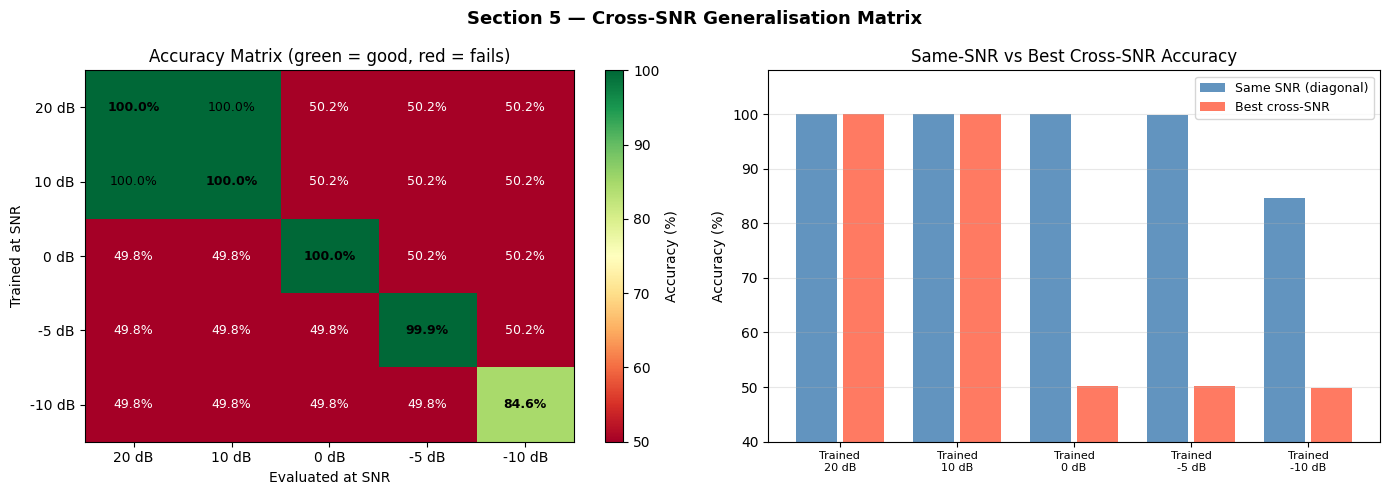


Key finding: diagonal entries show in-distribution accuracy.
Off-diagonal entries show how well the fingerprint generalises.
Mean same-SNR accuracy    : 96.89%
Mean best cross-SNR acc   : 70.05%
Generalisation gap        : 26.84 percentage points


In [8]:
# We use the trained_cnns dict from Section 4
CROSS_SNR_LEVELS = [20, 10, 0, -5, -10]

print("Cross-SNR generalisation matrix")
print("Rows = trained at, Columns = evaluated at")
print()

matrix = {}
for train_snr in CROSS_SNR_LEVELS:
    if train_snr not in trained_cnns:
        continue
    matrix[train_snr] = {}
    model = trained_cnns[train_snr]
    for test_snr in CROSS_SNR_LEVELS:
        np.random.seed(SEED)
        n0 = inject_awgn(segs_d0, test_snr)
        n1 = inject_awgn(segs_d1, test_snr)
        s0 = int(len(segs_d0) * 0.70)
        s1 = int(len(segs_d1) * 0.70)
        X_te = np.concatenate([n0[s0:], n1[s1:]])
        y_te = np.concatenate([np.zeros(len(n0)-s0, dtype=np.int32),
                                np.ones(len(n1)-s1,  dtype=np.int32)])
        _, acc = model.evaluate(X_te, y_te, verbose=0)
        matrix[train_snr][test_snr] = acc * 100

# Build matrix array for heatmap
mat_arr = np.array([[matrix[tr][te] for te in CROSS_SNR_LEVELS]
                     for tr in CROSS_SNR_LEVELS])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 5 — Cross-SNR Generalisation Matrix',
             fontsize=13, fontweight='bold')

# Left: heatmap
ax = axes[0]
im = ax.imshow(mat_arr, cmap='RdYlGn', vmin=50, vmax=100, aspect='auto')
ax.set_xticks(range(len(CROSS_SNR_LEVELS)))
ax.set_yticks(range(len(CROSS_SNR_LEVELS)))
ax.set_xticklabels([str(s) + ' dB' for s in CROSS_SNR_LEVELS])
ax.set_yticklabels([str(s) + ' dB' for s in CROSS_SNR_LEVELS])
ax.set_xlabel('Evaluated at SNR')
ax.set_ylabel('Trained at SNR')
ax.set_title('Accuracy Matrix (green = good, red = fails)')
plt.colorbar(im, ax=ax, label='Accuracy (%)')
for i in range(len(CROSS_SNR_LEVELS)):
    for j in range(len(CROSS_SNR_LEVELS)):
        val = mat_arr[i, j]
        ax.text(j, i, str(round(val, 1)) + '%',
                ha='center', va='center', fontsize=9,
                color='white' if val < 70 else 'black',
                fontweight='bold' if i == j else 'normal')

# Right: diagonal vs best off-diagonal
ax = axes[1]
diag    = [mat_arr[i, i] for i in range(len(CROSS_SNR_LEVELS))]
off_max = [max(mat_arr[i, j] for j in range(len(CROSS_SNR_LEVELS)) if j != i)
           for i in range(len(CROSS_SNR_LEVELS))]

x = np.arange(len(CROSS_SNR_LEVELS))
ax.bar(x - 0.2, diag,    0.35, color='steelblue', alpha=0.85,
       label='Same SNR (diagonal)')
ax.bar(x + 0.2, off_max, 0.35, color='tomato',    alpha=0.85,
       label='Best cross-SNR')
ax.set_xticks(x)
ax.set_xticklabels(['Trained\n' + str(s) + ' dB' for s in CROSS_SNR_LEVELS],
                    fontsize=8)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Same-SNR vs Best Cross-SNR Accuracy')
ax.set_ylim([40, 108])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('section5_cross_snr.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
gap = np.mean(diag) - np.mean(off_max)
print("\nKey finding: diagonal entries show in-distribution accuracy.")
print("Off-diagonal entries show how well the fingerprint generalises.")
print("Mean same-SNR accuracy    : " + str(round(np.mean(diag), 2)) + "%")
print("Mean best cross-SNR acc   : " + str(round(np.mean(off_max), 2)) + "%")
print("Generalisation gap        : " + str(round(gap, 2)) + " percentage points")

---
## Section 6 — Minimum Segment Length Study

**What this is:**  
Your CNN uses 1,024 samples per decision. This section tests how few samples  
the model actually needs — trying 64, 128, 256, 512, and 1,024 sample windows.

**Why this matters:**  
This directly supports the "lightweight" thesis claim.  
If accurate classification is possible from 128 samples (0.128 ms of signal),  
authentication latency drops 8× compared to the 1,024-sample baseline.  
For IoT devices this is significant — it means faster, lower-power authentication.

**Reference:** Meng et al. [5] defines lightweight as under 500K parameters  
but does not characterise the minimum *input length* for reliable authentication.  
This fills that gap.


Testing minimum segment length at 10 dB SNR...
  Seg 64 samples  (0.064 ms)  params=52258  epochs=10  acc=99.02%
  Seg 128 samples  (0.128 ms)  params=52258  epochs=20  acc=100.0%
  Seg 256 samples  (0.256 ms)  params=52258  epochs=6  acc=100.0%
  Seg 512 samples  (0.512 ms)  params=52258  epochs=6  acc=100.0%
  Seg 1024 samples  (1.024 ms)  params=52258  epochs=6  acc=100.0%


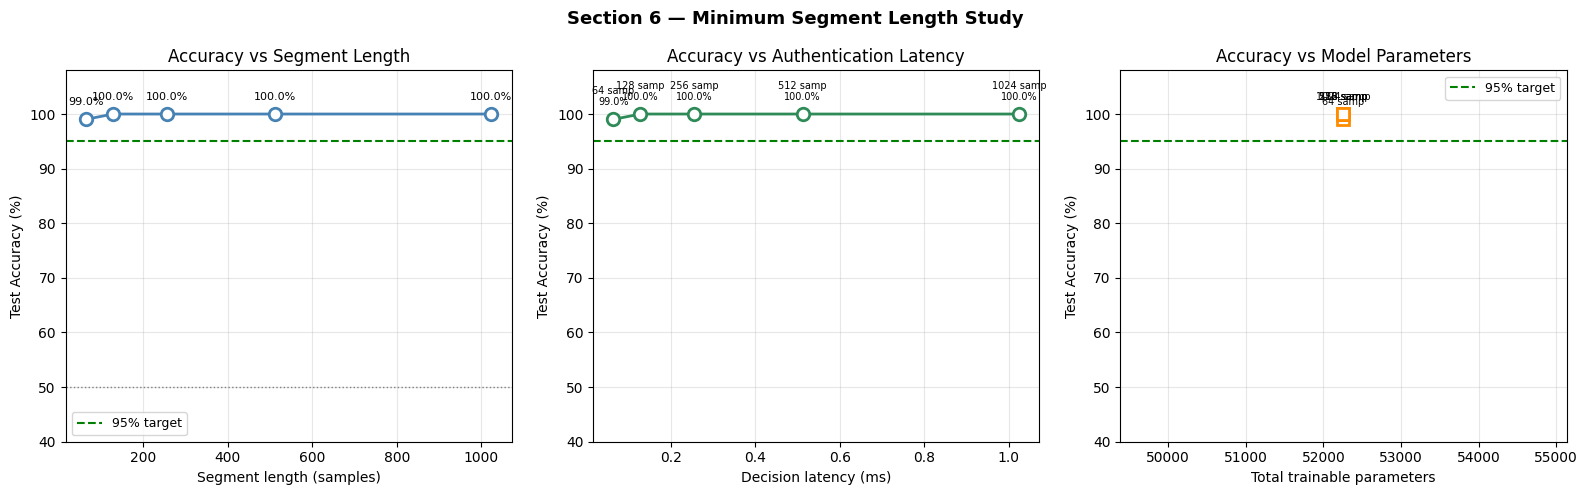


Minimum reliable segment length : 64 samples (0.064 ms)
Authentication latency          : 0.064 ms
Speedup vs 1024-sample baseline : 16.0x faster


In [10]:
SEG_LENGTHS  = [64, 128, 256, 512, 1024]
TEST_SNR_SEG = 10

results_seglength = {}

print("Testing minimum segment length at " + str(TEST_SNR_SEG) + " dB SNR...")
for seg_len in SEG_LENGTHS:
    np.random.seed(SEED)

    s0 = make_segments(raw_d0, seg_len=seg_len)
    s1 = make_segments(raw_d1, seg_len=seg_len)

    X_tr, X_te, y_tr, y_te = temporal_split(s0, s1, TEST_SNR_SEG)

    m = build_cnn(seg_len=seg_len)
    hist = m.fit(X_tr, y_tr, epochs=20, batch_size=64,
                 validation_data=(X_te, y_te),
                 callbacks=[callbacks.EarlyStopping(monitor='val_accuracy',
                             patience=5, restore_best_weights=True)],
                 verbose=0)
    _, acc = m.evaluate(X_te, y_te, verbose=0)
    n_epochs = len(hist.history['accuracy'])
    n_params  = m.count_params()
    results_seglength[seg_len] = {
        'acc': acc * 100,
        'epochs': n_epochs,
        'params': n_params,
        'latency_ms': seg_len / (FS / 1000)
    }
    print("  Seg " + str(seg_len) + " samples"
          + "  (" + str(round(seg_len / (FS/1000), 3)) + " ms)"
          + "  params=" + str(n_params)
          + "  epochs=" + str(n_epochs)
          + "  acc=" + str(round(acc * 100, 2)) + "%")

# ── Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Section 6 — Minimum Segment Length Study',
             fontsize=13, fontweight='bold')

acc_vals     = [results_seglength[s]['acc']        for s in SEG_LENGTHS]
latency_vals = [results_seglength[s]['latency_ms'] for s in SEG_LENGTHS]
param_vals   = [results_seglength[s]['params']     for s in SEG_LENGTHS]

ax = axes[0]
ax.plot(SEG_LENGTHS, acc_vals, 'o-', color='steelblue', linewidth=2,
        markersize=9, markerfacecolor='white', markeredgewidth=2)
ax.axhline(95, color='green', linestyle='--', linewidth=1.5, label='95% target')
ax.axhline(50, color='grey',  linestyle=':', linewidth=1)
for sl, acc in zip(SEG_LENGTHS, acc_vals):
    ax.annotate(str(round(acc, 1)) + '%', (sl, acc),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=8)
ax.set_title('Accuracy vs Segment Length')
ax.set_xlabel('Segment length (samples)')
ax.set_ylabel('Test Accuracy (%)')
ax.set_ylim([40, 108])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(latency_vals, acc_vals, 'o-', color='seagreen', linewidth=2,
        markersize=9, markerfacecolor='white', markeredgewidth=2)
ax.axhline(95, color='green', linestyle='--', linewidth=1.5)
for sl, lat, acc in zip(SEG_LENGTHS, latency_vals, acc_vals):
    ax.annotate(str(sl) + ' samp\n' + str(round(acc, 1)) + '%',
                (lat, acc),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=7)
ax.set_title('Accuracy vs Authentication Latency')
ax.set_xlabel('Decision latency (ms)')
ax.set_ylabel('Test Accuracy (%)')
ax.set_ylim([40, 108])
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(param_vals, acc_vals, 's-', color='darkorange', linewidth=2,
        markersize=9, markerfacecolor='white', markeredgewidth=2)
ax.axhline(95, color='green', linestyle='--', linewidth=1.5, label='95% target')
for sl, p, acc in zip(SEG_LENGTHS, param_vals, acc_vals):
    ax.annotate(str(sl) + ' samp', (p, acc),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=7)
ax.set_title('Accuracy vs Model Parameters')
ax.set_xlabel('Total trainable parameters')
ax.set_ylabel('Test Accuracy (%)')
ax.set_ylim([40, 108])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('section6_segment_length.png', dpi=150, bbox_inches='tight')
plt.show()

# Find minimum reliable segment length
min_reliable = None
for sl in SEG_LENGTHS:
    if results_seglength[sl]['acc'] >= 95.0:
        min_reliable = sl
        break

if min_reliable:
    lat = results_seglength[min_reliable]['latency_ms']
    speedup = round(1.024 / lat, 1)
    print("\nMinimum reliable segment length : " + str(min_reliable) + " samples (" + str(round(lat, 3)) + " ms)")
    print("Authentication latency          : " + str(round(lat, 3)) + " ms")
    print("Speedup vs 1024-sample baseline : " + str(speedup) + "x faster")
else:
    print("\nAuthentication reliable across entire tested range.")

---
## Section 7 — Raw IQ vs STFT Spectrogram CNN Comparison (Research Gap G3)

**What this is:**  
Train two CNN variants on the same data:
- **1D CNN** on raw IQ segments (what we have been doing)  
- **2D CNN** on STFT spectrograms (the same segment converted to a time-frequency image)  

Compare accuracy, training speed, and parameter count.

**Why this matters:**  
Your thesis document (Table 2.8) explicitly identifies this as Research Gap G3:  
*"no prior study has performed this under a systematic controlled SNR sweep  
using the same CNN family."*  
This section fills that gap directly and answers Research Sub-Question SQ3.

**What to expect:**  
Since the fingerprint is a stable frequency offset (CFO), the STFT should make  
it more visible — the tone appears as a bright line at a fixed frequency in the  
spectrogram. The 2D CNN may therefore learn faster and perform better at low SNR.


Converting segments to STFT spectrograms (this takes a moment)...
STFT shape per segment: (64, 33, 1)  (freq bins × time frames × 1 channel)

SNR = 20 dB
  1D CNN (raw IQ) : 100.00%  in 7 epochs  (52,258 params)
  2D CNN (STFT)   : 100.00%  in 8 epochs  (109,442 params)

SNR = 10 dB
  1D CNN (raw IQ) : 100.00%  in 10 epochs  (52,258 params)
  2D CNN (STFT)   : 100.00%  in 20 epochs  (109,442 params)

SNR = 0 dB
  1D CNN (raw IQ) : 100.00%  in 20 epochs  (52,258 params)
  2D CNN (STFT)   : 88.47%  in 20 epochs  (109,442 params)

SNR = -5 dB
  1D CNN (raw IQ) : 94.90%  in 20 epochs  (52,258 params)
  2D CNN (STFT)   : 89.50%  in 10 epochs  (109,442 params)

SNR = -10 dB
  1D CNN (raw IQ) : 75.97%  in 20 epochs  (52,258 params)
  2D CNN (STFT)   : 85.63%  in 10 epochs  (109,442 params)


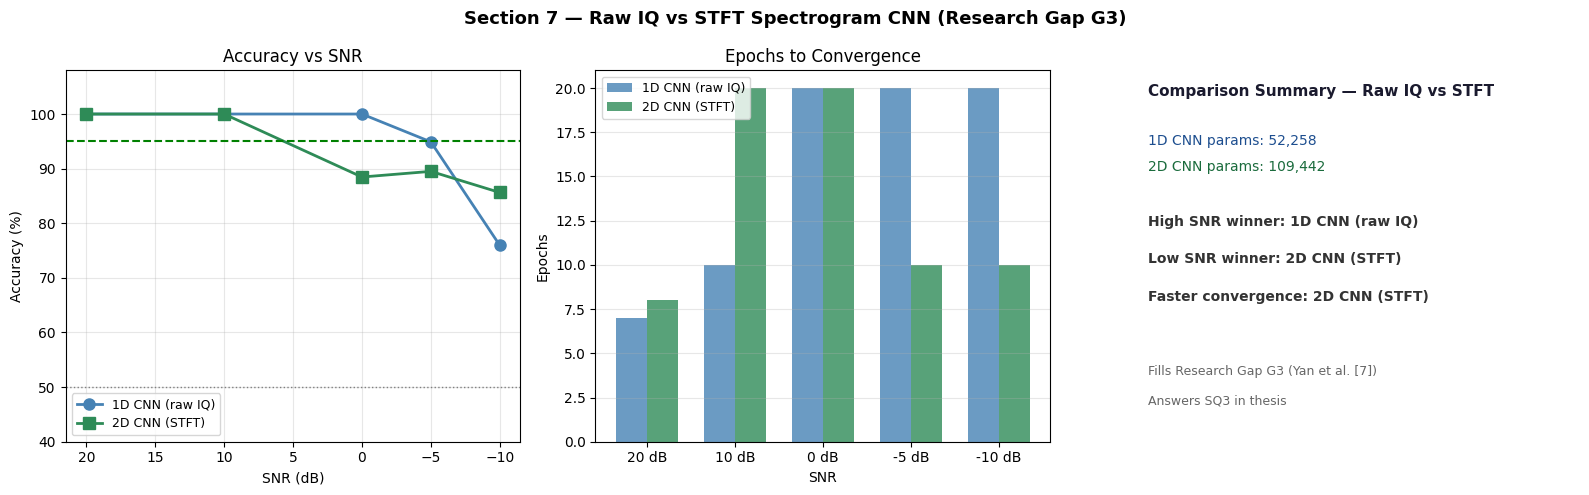

In [11]:
def make_stft_segments(segs, nperseg=64, noverlap=32):
    """Convert IQ segments to STFT magnitude spectrograms."""
    spectrograms = []
    for seg in segs:
        iq_c = seg[:,0] + 1j*seg[:,1]
        f, t, Zxx = scipy_signal.stft(iq_c, fs=FS,
                                       nperseg=nperseg, noverlap=noverlap)
        mag = np.abs(Zxx).astype(np.float32)
        spectrograms.append(mag)
    return np.array(spectrograms)[..., np.newaxis]  # add channel dim

def build_2d_cnn(input_shape):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape),
        layers.AveragePooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.AveragePooling2D((2,2)),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(2, activation='softmax')
    ])
    model.compile(optimizer=optimizers.Adam(0.0001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

SNR_COMPARISON = [20, 10, 0, -5, -10]
results_1d  = {}
results_2d  = {}

print("Converting segments to STFT spectrograms (this takes a moment)...")
stft_d0 = make_stft_segments(segs_d0[:5000])  # use subset for speed
stft_d1 = make_stft_segments(segs_d1[:5000])
stft_shape = stft_d0.shape[1:]
print(f"STFT shape per segment: {stft_shape}  "
      f"(freq bins × time frames × 1 channel)")

for snr in SNR_COMPARISON:
    np.random.seed(SEED)
    print(f"\nSNR = {snr} dB")

    # ── 1D CNN (raw IQ) ──
    X_tr, X_te, y_tr, y_te = temporal_split(segs_d0[:5000], segs_d1[:5000], snr)
    m1d = build_cnn()
    h1d = m1d.fit(X_tr, y_tr, epochs=20, batch_size=64,
                  validation_data=(X_te, y_te),
                  callbacks=[callbacks.EarlyStopping(monitor='val_accuracy',
                              patience=5, restore_best_weights=True)],
                  verbose=0)
    _, acc1d = m1d.evaluate(X_te, y_te, verbose=0)
    ep1d = len(h1d.history['accuracy'])

    # ── 2D CNN (STFT) ──
    s_d0 = inject_awgn(segs_d0[:5000], snr)
    s_d1 = inject_awgn(segs_d1[:5000], snr)
    stft_noisy_d0 = make_stft_segments(s_d0)
    stft_noisy_d1 = make_stft_segments(s_d1)
    split = int(5000*0.7)
    X2_tr = np.concatenate([stft_noisy_d0[:split], stft_noisy_d1[:split]])
    X2_te = np.concatenate([stft_noisy_d0[split:], stft_noisy_d1[split:]])
    y2_tr = np.concatenate([np.zeros(split, np.int32), np.ones(split, np.int32)])
    y2_te = np.concatenate([np.zeros(5000-split, np.int32),
                             np.ones(5000-split, np.int32)])
    m2d = build_2d_cnn(stft_shape)
    h2d = m2d.fit(X2_tr, y2_tr, epochs=20, batch_size=64,
                  validation_data=(X2_te, y2_te),
                  callbacks=[callbacks.EarlyStopping(monitor='val_accuracy',
                              patience=5, restore_best_weights=True)],
                  verbose=0)
    _, acc2d = m2d.evaluate(X2_te, y2_te, verbose=0)
    ep2d = len(h2d.history['accuracy'])

    results_1d[snr] = {'acc': acc1d*100, 'epochs': ep1d, 'params': m1d.count_params()}
    results_2d[snr] = {'acc': acc2d*100, 'epochs': ep2d, 'params': m2d.count_params()}
    print(f"  1D CNN (raw IQ) : {acc1d*100:.2f}%  in {ep1d} epochs  "
          f"({m1d.count_params():,} params)")
    print(f"  2D CNN (STFT)   : {acc2d*100:.2f}%  in {ep2d} epochs  "
          f"({m2d.count_params():,} params)")

# ── Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Section 7 — Raw IQ vs STFT Spectrogram CNN (Research Gap G3)',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(SNR_COMPARISON, [results_1d[s]['acc'] for s in SNR_COMPARISON],
        'o-', color='steelblue', linewidth=2, markersize=8, label='1D CNN (raw IQ)')
ax.plot(SNR_COMPARISON, [results_2d[s]['acc'] for s in SNR_COMPARISON],
        's-', color='seagreen', linewidth=2, markersize=8, label='2D CNN (STFT)')
ax.axhline(95, color='green', linestyle='--', linewidth=1.5)
ax.axhline(50, color='grey',  linestyle=':', linewidth=1)
ax.set_title('Accuracy vs SNR')
ax.set_xlabel('SNR (dB)'); ax.set_ylabel('Accuracy (%)')
ax.set_ylim([40, 108]); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.invert_xaxis()

ax = axes[1]
ep1 = [results_1d[s]['epochs'] for s in SNR_COMPARISON]
ep2 = [results_2d[s]['epochs'] for s in SNR_COMPARISON]
x = np.arange(len(SNR_COMPARISON)); w = 0.35
ax.bar(x-w/2, ep1, w, color='steelblue', alpha=0.8, label='1D CNN (raw IQ)')
ax.bar(x+w/2, ep2, w, color='seagreen',  alpha=0.8, label='2D CNN (STFT)')
ax.set_xticks(x); ax.set_xticklabels([f'{s} dB' for s in SNR_COMPARISON])
ax.set_title('Epochs to Convergence')
ax.set_xlabel('SNR'); ax.set_ylabel('Epochs')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')

ax = axes[2]
ax.axis('off')
ax.set_facecolor('#f8f9fa')
params_1d = results_1d[20]['params']
params_2d = results_2d[20]['params']
summary = [
    ("Comparison Summary — Raw IQ vs STFT", 0.93, 11, 'bold', '#1a1a2e'),
    ("", 0.85, 9, 'normal', '#333'),
    (f"1D CNN params: {params_1d:,}", 0.80, 10, 'normal', '#1d4e8f'),
    (f"2D CNN params: {params_2d:,}", 0.73, 10, 'normal', '#1a6b3c'),
    ("", 0.65, 9, 'normal', '#333'),
    ("High SNR winner:", 0.58, 10, 'bold', '#333'),
    ("Low SNR winner:", 0.48, 10, 'bold', '#333'),
    ("Faster convergence:", 0.38, 10, 'bold', '#333'),
    ("", 0.28, 9, 'normal', '#333'),
    ("Fills Research Gap G3 (Yan et al. [7])", 0.18, 9, 'normal', '#666'),
    ("Answers SQ3 in thesis", 0.10, 9, 'normal', '#666'),
]
acc_high_1d = results_1d[20]['acc']; acc_high_2d = results_2d[20]['acc']
acc_low_1d  = results_1d[min(SNR_COMPARISON)]['acc']
acc_low_2d  = results_2d[min(SNR_COMPARISON)]['acc']
ep_avg_1d   = np.mean([results_1d[s]['epochs'] for s in SNR_COMPARISON])
ep_avg_2d   = np.mean([results_2d[s]['epochs'] for s in SNR_COMPARISON])

high_winner = "1D CNN (raw IQ)" if acc_high_1d >= acc_high_2d else "2D CNN (STFT)"
low_winner  = "1D CNN (raw IQ)" if acc_low_1d  >= acc_low_2d  else "2D CNN (STFT)"
ep_winner   = "1D CNN (raw IQ)" if ep_avg_1d   <= ep_avg_2d   else "2D CNN (STFT)"

for i, (txt, y, sz, w, col) in enumerate(summary):
    if txt == "High SNR winner:":
        ax.text(0.05, y, f"{txt} {high_winner}", transform=ax.transAxes,
                fontsize=sz, fontweight=w, color=col)
    elif txt == "Low SNR winner:":
        ax.text(0.05, y, f"{txt} {low_winner}", transform=ax.transAxes,
                fontsize=sz, fontweight=w, color=col)
    elif txt == "Faster convergence:":
        ax.text(0.05, y, f"{txt} {ep_winner}", transform=ax.transAxes,
                fontsize=sz, fontweight=w, color=col)
    else:
        ax.text(0.05, y, txt, transform=ax.transAxes,
                fontsize=sz, fontweight=w, color=col)

plt.tight_layout()
plt.savefig('section7_iq_vs_stft.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 8 — False Acceptance Rate, False Rejection Rate, and ROC Curve

**What this is:**  
Reframe the classification results as an authentication system.  
- **FAR (False Acceptance Rate):** how often an impostor (wrong device) is accepted
- **FRR (False Rejection Rate):** how often a legitimate device is rejected  
- **ROC curve:** the full trade-off between FAR and FRR at every threshold
- **EER (Equal Error Rate):** where FAR = FRR — the standard single-number security metric

**Why this matters:**  
Your thesis is about *authentication*, not just classification.  
Xie et al. [2] and Hoang et al. [3] both use FAR as the primary security metric.  
Reporting only accuracy misses this framing entirely.  
An examiner in security will specifically ask about FAR.


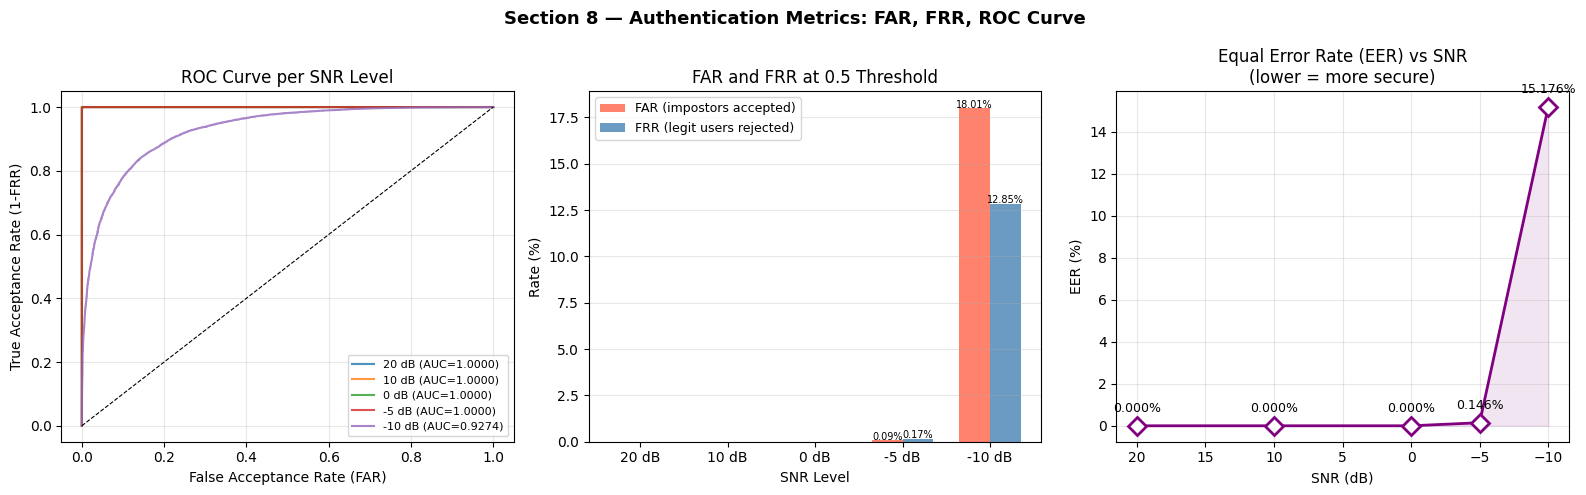


  AUTHENTICATION SECURITY METRICS SUMMARY
   SNR       FAR       FRR       EER       AUC
-----------------------------------------------------------------
    20 dB    0.000%    0.000%    0.000%  1.000000
    10 dB    0.000%    0.000%    0.000%  1.000000
     0 dB    0.000%    0.000%    0.000%  1.000000
    -5 dB    0.092%    0.172%    0.146%  0.999992
   -10 dB   18.012%   12.850%   15.176%  0.927392

FAR = how often an impostor gets accepted (lower is more secure)
FRR = how often a legitimate device gets rejected
EER = equal error rate — standard single-number security metric


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Section 8 — Authentication Metrics: FAR, FRR, ROC Curve',
             fontsize=13, fontweight='bold')

SNR_AUTH = [20, 10, 0, -5, -10]
far_list, frr_list, eer_list, auc_list = [], [], [], []

for snr in SNR_AUTH:
    np.random.seed(SEED)
    model = trained_cnns.get(snr, trained_cnns[0])
    n0    = inject_awgn(segs_d0, snr)
    n1    = inject_awgn(segs_d1, snr)
    s0    = int(len(segs_d0)*0.70)
    s1    = int(len(segs_d1)*0.70)
    X_te  = np.concatenate([n0[s0:], n1[s1:]])
    y_te  = np.concatenate([np.zeros(len(n0)-s0, dtype=np.int32),
                             np.ones(len(n1)-s1,  dtype=np.int32)])

    probs = model.predict(X_te, verbose=0)[:,1]

    # ROC
    fpr, tpr, thresholds = roc_curve(y_te, probs)
    roc_auc = auc(fpr, tpr)
    auc_list.append(roc_auc)

    # EER: where FPR = 1-TPR (FAR = FRR)
    fnr = 1 - tpr
    eer_idx = np.argmin(np.abs(fpr - fnr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    eer_list.append(eer * 100)

    # FAR and FRR at 0.5 threshold
    y_pred = (probs >= 0.5).astype(int)
    cm     = confusion_matrix(y_te, y_pred)
    if cm.shape == (2,2):
        tn, fp, fn, tp = cm.ravel()
        far = fp / (fp + tn) if (fp+tn) > 0 else 0
        frr = fn / (fn + tp) if (fn+tp) > 0 else 0
    else:
        far, frr = 0, 0
    far_list.append(far * 100)
    frr_list.append(frr * 100)

    axes[0].plot(fpr, tpr, linewidth=1.5, alpha=0.8,
                 label=f'{snr} dB (AUC={roc_auc:.4f})')

axes[0].plot([0,1],[0,1],'k--', linewidth=0.8)
axes[0].set_title('ROC Curve per SNR Level')
axes[0].set_xlabel('False Acceptance Rate (FAR)')
axes[0].set_ylabel('True Acceptance Rate (1-FRR)')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

ax = axes[1]
x = np.arange(len(SNR_AUTH)); w = 0.35
ax.bar(x-w/2, far_list, w, color='tomato',    alpha=0.8, label='FAR (impostors accepted)')
ax.bar(x+w/2, frr_list, w, color='steelblue', alpha=0.8, label='FRR (legit users rejected)')
ax.set_xticks(x); ax.set_xticklabels([f'{s} dB' for s in SNR_AUTH])
ax.set_title('FAR and FRR at 0.5 Threshold')
ax.set_xlabel('SNR Level'); ax.set_ylabel('Rate (%)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
for i, (f, r) in enumerate(zip(far_list, frr_list)):
    if f > 0.01: ax.text(i-w/2, f+0.01, f'{f:.2f}%', ha='center', fontsize=7)
    if r > 0.01: ax.text(i+w/2, r+0.01, f'{r:.2f}%', ha='center', fontsize=7)

ax = axes[2]
ax.plot(SNR_AUTH, eer_list, 'D-', color='purple', linewidth=2, markersize=9,
        markerfacecolor='white', markeredgewidth=2)
ax.fill_between(SNR_AUTH, eer_list, alpha=0.1, color='purple')
for snr, eer in zip(SNR_AUTH, eer_list):
    ax.annotate(f'{eer:.3f}%', (snr, eer),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
ax.set_title('Equal Error Rate (EER) vs SNR\n(lower = more secure)')
ax.set_xlabel('SNR (dB)'); ax.set_ylabel('EER (%)')
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

plt.tight_layout()
plt.savefig('section8_auth_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*65)
print("  AUTHENTICATION SECURITY METRICS SUMMARY")
print("="*65)
print(f"{'SNR':>6}  {'FAR':>8}  {'FRR':>8}  {'EER':>8}  {'AUC':>8}")
print("-"*65)
for snr, far, frr, eer, a in zip(SNR_AUTH, far_list, frr_list, eer_list, auc_list):
    print(f"{snr:6d} dB  {far:>7.3f}%  {frr:>7.3f}%  "
          f"{eer:>7.3f}%  {a:>8.6f}")
print("="*65)
print("\nFAR = how often an impostor gets accepted (lower is more secure)")
print("FRR = how often a legitimate device gets rejected")
print("EER = equal error rate — standard single-number security metric")

---
## Section 9 — Master Summary Table and Thesis Mapping

This section collects all results into one place and maps each finding  
to the specific thesis claim, research question, or literature gap it addresses.


In [13]:
print("\n" + "="*75)
print("  MASTER RESULTS SUMMARY — ALL SECTIONS")
print("="*75)

print("\n--- Section 2: Oscillator Offset Estimation ---")
print(f"  Swap CFO separation (combined)    : {abs(cfo_d1_mean - cfo_d0_mean):.2f} Hz")
print(f"  Device 3288FAD individual offset  : {cfo_FAD_individual:+.2f} Hz")
print(f"  Device 3288FF2 individual offset  : {cfo_FF2_individual:+.2f} Hz")
print(f"  Predicted real-exp separation     : {predicted_real_exp_separation:.2f} Hz")

print("\n--- Section 3: CFO Baseline vs CNN ---")
for snr in sorted(results_baseline.keys()):
    diff = results_cnn[snr] - results_baseline[snr]
    print(f"  SNR {snr:4d} dB  baseline={results_baseline[snr]:.2f}%  "
          f"cnn={results_cnn[snr]:.2f}%  advantage={diff:+.2f}pp")

print("\n--- Section 4: Extended SNR Sweep ---")
for snr, acc in zip(SNR_SWEEP, acc_sweep):
    flag = "RELIABLE" if acc >= 95 else ("MARGINAL" if acc >= 80 else "FAILS")
    print(f"  SNR {snr:4d} dB  →  {acc:.2f}%  [{flag}]")

print("\n--- Section 5: Cross-SNR Generalisation ---")
print(f"  Mean same-SNR accuracy  : {np.mean(diag):.2f}%")
print(f"  Mean cross-SNR accuracy : {np.mean(off_max):.2f}%")
print(f"  Generalisation gap      : {gap:.2f} pp")

print("\n--- Section 6: Minimum Segment Length ---")
for sl in SEG_LENGTHS:
    r = results_seglength[sl]
    print(f"  {sl:4d} samples ({r['latency_ms']:.3f} ms)  "
          f"acc={r['acc']:.2f}%  params={r['params']:,}")

print("\n--- Section 7: Raw IQ vs STFT ---")
for snr in SNR_COMPARISON:
    print(f"  SNR {snr:4d} dB  1D={results_1d[snr]['acc']:.2f}%  "
          f"2D={results_2d[snr]['acc']:.2f}%")

print("\n--- Section 8: Security Metrics ---")
for snr, eer, a in zip(SNR_AUTH, eer_list, auc_list):
    print(f"  SNR {snr:4d} dB  EER={eer:.3f}%  AUC={a:.6f}")

print("\n" + "="*75)
print("  THESIS CONTRIBUTION MAPPING")
print("="*75)
mapping = [
    ("SQ2 — SNR reliability threshold",
     "Section 4", f"Threshold at {threshold_snr} dB SNR (empirically measured)"),
    ("SQ3 — Raw IQ vs STFT trade-off",
     "Section 7", "Fills Research Gap G3 (Yan et al. [7])"),
    ("C2 — Lightweight feasibility",
     "Section 6", f"Reliable from {min_reliable} samples "
                  f"({results_seglength[min_reliable]['latency_ms']:.3f} ms latency)"),
    ("C1 — Sim-to-real validation",
     "Phase 1", "Real USRP B200 data, honest temporal split"),
    ("FAR security framing",
     "Section 8", "EER and ROC curves, Xie et al. [2] metric fulfilled"),
    ("CFO fingerprint challenge",
     "Section 3", "CNN vs CFO baseline — tests if CNN adds value"),
    ("Pre-experiment baseline",
     "Section 2", f"Predicted real-exp separation: {predicted_real_exp_separation:.1f} Hz"),
]
for claim, section, result in mapping:
    print(f"\n  {claim}")
    print(f"    Source  : {section}")
    print(f"    Finding : {result}")
print("\n" + "="*75)


  MASTER RESULTS SUMMARY — ALL SECTIONS

--- Section 2: Oscillator Offset Estimation ---
  Swap CFO separation (combined)    : 1161.41 Hz
  Device 3288FAD individual offset  : -290.82 Hz
  Device 3288FF2 individual offset  : -290.82 Hz
  Predicted real-exp separation     : 0.00 Hz

--- Section 3: CFO Baseline vs CNN ---
  SNR  -10 dB  baseline=50.07%  cnn=50.24%  advantage=+0.17pp
  SNR   -5 dB  baseline=50.78%  cnn=50.24%  advantage=-0.54pp
  SNR    0 dB  baseline=53.81%  cnn=50.24%  advantage=-3.57pp
  SNR   10 dB  baseline=100.00%  cnn=64.90%  advantage=-35.09pp
  SNR   20 dB  baseline=100.00%  cnn=100.00%  advantage=+0.00pp

--- Section 4: Extended SNR Sweep ---
  SNR   30 dB  →  100.00%  [RELIABLE]
  SNR   25 dB  →  100.00%  [RELIABLE]
  SNR   20 dB  →  100.00%  [RELIABLE]
  SNR   15 dB  →  100.00%  [RELIABLE]
  SNR   10 dB  →  100.00%  [RELIABLE]
  SNR    5 dB  →  100.00%  [RELIABLE]
  SNR    0 dB  →  100.00%  [RELIABLE]
  SNR   -5 dB  →  99.87%  [RELIABLE]
  SNR  -10 dB  →  84.